In [1]:
import json
import os

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np

from koger_detection.utils.dataset import scale_annotations_and_images
from koger_detection.utils.dataset import get_bounding_box_areas
from koger_detection.utils.json import combine_jsons

# Load local .env file that contains local path "ROOT" and "LABELBOX_API_KEY"
load_dotenv()

True

In [2]:
# ROOT specified in .env file shuld be full path to dropbox folder
#os.environ.get("PROJECT_ROOT")

In [3]:
# These names correspond to sets of labelbox projects where each set has a same type of filming style (height, camera)
# Can comment out filming styles to exclude them from processing
filming_styles = [
    "pond-survey-combined-with-bear", # about 30 meters using the higest res still image mode Mavic 3 (no annotations of bears but the class is present)
    #"high-altitude-combined", # about 50 (?) meters filming video with mavic 2 (salmon and bears)
    #"big-confluence-2023", # about 25 meters 5k Mavic 3 video (just salmon annotated but bear class is present)
    "confluence_46_annotations.coco_fixed"
    ]

#filming_styles = ["confluence_test_annotations.coco_fixed"]
# The filming style that the other annotations will be scaled to match
focal_style = "confluence_46_annotations.coco_fixed"
#focal_style = "big-confluence-2023"

# Output json file name
output_json_name = "scaled-with-newConfluence-test.json"

# Folder where raw json annotation files are stored
annotation_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), "annotations")

images_folder = os.path.join(annotation_folder, "images_with_confluence")

### Resize annotations to match focal_style annotations

There are 775 annotated images with 20592 annotations in the JSON files.
775 images added to new .json
20592 annotations added to new .json


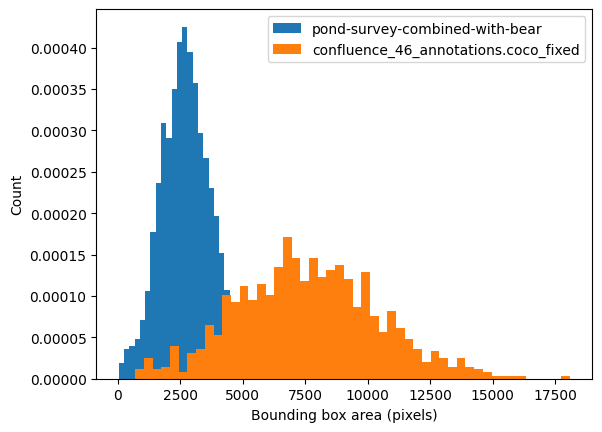

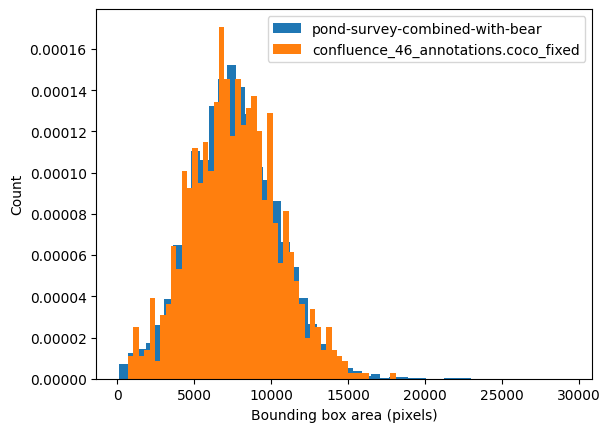

In [4]:
raw_annotations = {}

plot = True

# Open annotations and compute median bounding box area for each filming style
for filming_style in filming_styles:
    # get the corresponding json file
    json_file = os.path.join(annotation_folder, f"{filming_style}.json")
    # Load the json file
    with open(json_file) as f:
        coco_anns = json.load(f)
    bbox_areas = get_bounding_box_areas(coco_anns)
    median_area = np.median(bbox_areas)
    raw_annotations[filming_style] = {
        "coco_anns": coco_anns,
        "median_area": median_area,
        "original_json_file": json_file
    }
    if plot:
        plt.hist(bbox_areas, bins=50, density=True, label=filming_style)
        plt.xlabel("Bounding box area (pixels)")
        plt.ylabel("Count")
        plt.legend()

# Rescale other filming styles to match the focal style based on median bounding box area

os.makedirs(images_folder, exist_ok=True)

target_median = raw_annotations[focal_style]["median_area"]
for filming_style in filming_styles:
    if filming_style == focal_style:
        raw_annotations[filming_style]["scale"] = 1.0
        raw_annotations[filming_style]["scaled_json_file"] = raw_annotations[filming_style]["original_json_file"]
        continue
    scale = np.sqrt(target_median / raw_annotations[filming_style]["median_area"])
    scaled_json_file = os.path.join(annotation_folder, f"{filming_style}-scaled-{scale}.json")
    scale_annotations_and_images(raw_annotations[filming_style]["coco_anns"], 
                                 scale, images_folder, scaled_json_file)
    raw_annotations[filming_style]["scale"] = scale
    raw_annotations[filming_style]["scaled_json_file"] = scaled_json_file

# Optionally view updated scaled json files
if plot:
    plt.figure()
    for filming_style in filming_styles:
        with open(raw_annotations[filming_style]["scaled_json_file"]) as f:
            coco_anns = json.load(f)
        bbox_areas = get_bounding_box_areas(coco_anns)
        plt.hist(bbox_areas, bins=50, density=True, label=filming_style)
        plt.xlabel("Bounding box area (pixels)")
        plt.ylabel("Count")
        plt.legend()

scaled_json_files = [f["scaled_json_file"] for f in raw_annotations.values()]
combined_json_file = os.path.join(annotation_folder, output_json_name)
combine_jsons(scaled_json_files, out_file=combined_json_file)


### Create train and val split

In [5]:
from koger_detection.utils.json import create_train_val_split

In [6]:
json_file = os.path.join(annotation_folder, combined_json_file)
fraction_val = .15
create_train_val_split(json_file, fraction_val, train_name="train.json", 
                       val_name="val.json")

There are 775 annotated images.
640 training images with 17312 annotations.
129 validation images with 3280 annotations.


## Bonus: Visualize annotations

In [7]:
import os

import matplotlib.pyplot as plt

import torch
# Note: also need to install pycocotools
from torchvision import datasets
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_convert
import torchvision.transforms.functional as F

In [8]:
example_json = os.path.join(annotation_folder, f"val.json")
image_folder = images_folder #os.path.join(annotation_folder, "images")

dataset = datasets.CocoDetection(root=image_folder, annFile=example_json)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


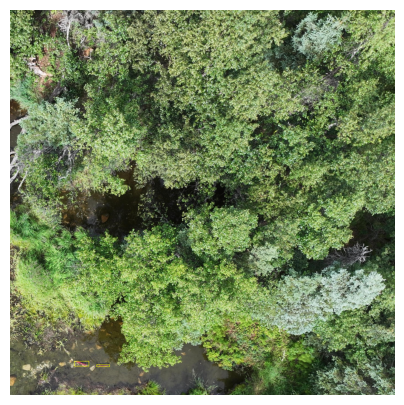

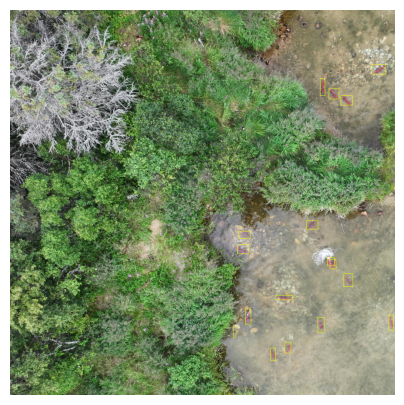

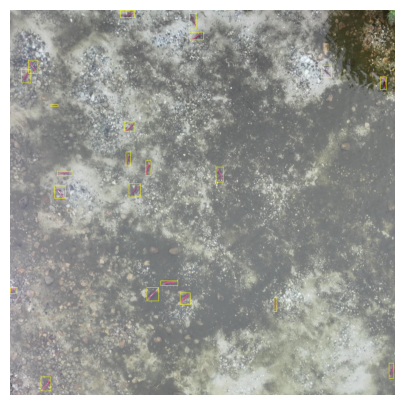

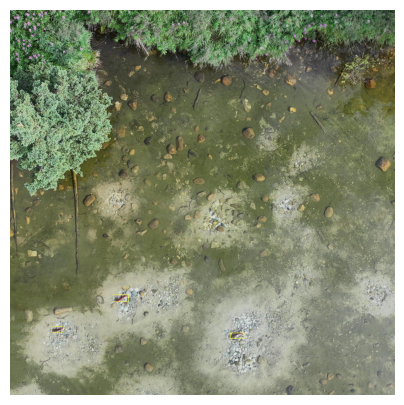

In [9]:
for im_ind in range(0, 4):
    ann = dataset[im_ind]
    if len(ann[1]) >= 1:
        boxes = torch.vstack([box_convert(torch.tensor(a['bbox']), "xywh", "xyxy") for a in ann[1]])
        labels = [a['category_id'] for a in ann[1]]
        colors = [(230,215,255), (255, 255, 0), (255, 0, 255), (255, 155, 0), (255, 0, 155),(255, 155, 155), (255, 255, 155)]
        box_colors = [colors[l-1] for l in labels]
    image = F.pil_to_tensor(ann[0])
    if len(ann[1]) >= 1:
        image = draw_bounding_boxes((image).type(torch.uint8), 
                                      boxes=boxes, colors=box_colors,
                                      width=4)
    else:
        print("No annotations")
    plt.figure(figsize=(5, 5))
    plt.imshow(F.to_pil_image(image))
    plt.axis('off')  